## fastText (Bojanowski et al, 2016)
- Facebook AI Research (FAIR) lab (now Meta AI)
- vector representation based on the skip-gram and sub-word models
- represent the word with its character n-grams other the word itself such that word morphologies are also
represented
- solves the problem of unknown words

In [53]:
!uv add gensim matplotlib -q

In [54]:
import os
print(os.getcwd())

/Users/normanjazul/Documents/vscode/Python/Notebooks/NLP/EXERCISES/Exercise-2b


In [ ]:
# Load trained fasttext model
from gensim.models import FastText

#Download ngram model first
ft_model = FastText.load("fasttext_model.model")

In [56]:
# Show fastText embedding of a word; What is the length (dimension of the embedding)?
print(ft_model.wv['gugma'])
print(len(ft_model.wv['gugma']))

[ -2.7564256   -4.618285    -1.1427592   -0.5427287   -0.04694757
   3.1071086   -2.0400834   -1.0820453    2.1941552    0.51963943
   1.3211627   -1.3595226    5.6952505    1.7599733    0.13901779
   1.9100058    2.2680278   -0.56811047   1.4128095   -1.673112
   3.0015736    2.4705446    1.7853276   -2.1192257    1.2856306
  -0.69525826   0.24469882   0.53853136   3.9994013    2.6258874
  -1.4158323    1.3195001   -0.32597163   4.0818686   -1.0780324
   3.15826      1.0793123    0.62976235  -1.1783065    0.20767471
   0.59388715  -1.0251786   -3.188563    -0.46267867  -0.08656679
   3.0688386   -1.3076632   -0.4020966    4.9953976   -2.451449
  -3.9778998   -0.1721275    6.141824    -1.2101083    2.0752988
  -1.4059633    1.40175      1.5032362   -0.92677355   0.2035495
   2.8103256    1.2807584   -0.8025608   -1.1244032   -1.7147558
   0.49750066 -10.049897    -1.6075433   -0.22325243   0.75251144
   0.23057725  -1.0248421    0.33780962  -2.6204722   -1.2859955
  -1.6069834    3.295

# Word Similarity #
Target Words: 
1. gugma
2. kalinaw
3. malinawon
4. kagawasan
5. panimalay
6. kaluwasan
7. luwas
8. dios
9. babaye

In [57]:
# Perform Similarity and Analogy Evaluations just like Word2Vec

# b. What are the top 10 similar words for each target word? Describe the kind of 

target_words = [
    "gugma",
    "kalinaw",
    "malinawon",
    "kagawasan",
    "panimalay",
    "kaluwasan",
    "luwas",
    "dios",
    "babaye"
]

print("Score close to 1.0: Identical direction (identical meaning)")
print("Score close to 0.0: Completely unrelated/orthogonal")
print("Score close to -1.0: Exact opposites\n")

for word in target_words:
    print(f"Top 10 words similar to '{word}':")
    if word in ft_model.wv:
        similar_words = ft_model.wv.most_similar(word, topn=10)
        itr = 1
        for similar_word, cosine_similarity_score in similar_words:
            print(f"{itr}. {similar_word}: {cosine_similarity_score:.4f}")
            itr+=1
        print()
    else:
        print(f"Word '{word}' not found in vocabulary.\n")

# I observed that fastText's similarity results are heavily dominated
# by morphological variants rather than semantically different words.
# For 'gugma', the top results are 'gugmaha', 'gugmang', and 'gugmaong'
# which are just inflected forms of the same root word. This pattern
# repeats across all target words (luwas -> luwasa, maluwas, pagluwas).
# Unlike Word2Vec which grouped thematically related words like 'paglaum'
# and 'pagtoo', fastText prioritizes character n-gram overlap, making it
# excellent at capturing word morphology but weaker at finding words
# with related meaning from completely different roots.

Score close to 1.0: Identical direction (identical meaning)
Score close to 0.0: Completely unrelated/orthogonal
Score close to -1.0: Exact opposites

Top 10 words similar to 'gugma':
1. gugmaha: 0.8637
2. gugmang: 0.8028
3. gugmaong: 0.7413
4. paghigugma: 0.7208
5. gma: 0.7120
6. ginahigugma: 0.7011
7. mahigugma: 0.6829
8. gihigugma: 0.6824
9. paghigugmaa: 0.6790
10. mahagugma: 0.6785

Top 10 words similar to 'kalinaw':
1. malinaw: 0.7198
2. pagkamalinawon: 0.6999
3. magapalinaw: 0.6760
4. nagapalinaw: 0.6653
5. malinawong: 0.6640
6. kalinyasan: 0.6622
7. pagkahanaw: 0.6590
8. nakapalinaw: 0.6583
9. kalingawan: 0.6578
10. pagalinawon: 0.6510

Top 10 words similar to 'malinawon':
1. malinawong: 0.9163
2. magamalinawon: 0.8705
3. magmalinawon: 0.8673
4. pagalinawon: 0.8265
5. malinaw: 0.8184
6. pagkamalinawon: 0.8168
7. magmalinaw: 0.7288
8. pagauhawon: 0.7086
9. pasinawon: 0.7037
10. maliputon: 0.6961

Top 10 words similar to 'kagawasan':
1. kinagawasan: 0.8436
2. kagawian: 0.7802
3. ki

# Word Analogy #

[model.most_similar(positive=[y1, x2], negative=[x1])]<br>
Evaluate the model using word analogies. Example analogies are provided for you.
You may look for other analogies to use as test cases.
1. synonym             -- amahan:lalake::inahan:?
2. antonymity          -- amahan:inahan::lalake:?
3. part-whole          -- bahay:atip::kotse:?                        
4. superclass-subclass -- hayop:aso::tao:?
5. used-for            -- gupit:gunting::sulat:? 

In [58]:
# c. Describe the ability of the model to capture synonyms. Use 2-3 example analogies.

synonym_analogies = {
    "amahan : lalake :: inahan : ?": (['lalake', 'inahan'], ['amahan'], "babaye"),
    "langit : kalangitan :: yuta : ?": (['kalangitan', 'yuta'], ['langit'], "kalibutan"),
    "bana : lalake :: asawa : ?": (['lalake', 'asawa'], ['bana'], "babaye")
}

for analogy, (pos, neg, expected) in synonym_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    synonyms = ft_model.wv.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for synonym, cosine_similarity_score in synonyms:
        print(f"{itr}. {synonym}: {cosine_similarity_score:.4f}")
        itr+=1
    print()

# I observed that fastText performs poorly on synonym analogies due
# to its subword bias. For 'amahan:lalake::inahan:?', the model
# returned 'alalake' at #1 and 'lalke' at #2, which are just
# character-level variations of 'lalake' rather than actual analogical
# results. The expected answer 'babaye' only appeared at #8 with a
# low score of 0.4250. The subword mechanism causes the model to
# match n-gram fragments instead of reasoning through semantic
# relationships, which makes it worse than Word2Vec at this task.

Analogy: amahan : lalake :: inahan : ? (Expected: 'babaye')
1. alalake: 0.6304
2. lalke: 0.5962
3. lalakeng: 0.5500
4. lalaki: 0.5401
5. lake: 0.4744
6. lala: 0.4604
7. lalaking: 0.4502
8. babaye: 0.4250
9. isigkalalaki: 0.4094
10. minahal: 0.4025

Analogy: langit : kalangitan :: yuta : ? (Expected: 'kalibutan')
1. yutan: 0.7168
2. yutang: 0.6414
3. kayutaan: 0.6340
4. yubitan: 0.5636
5. kalaptan: 0.5579
6. yutaa: 0.5414
7. kaluta: 0.5368
8. kalibutan: 0.5354
9. kalabutan: 0.5346
10. kadagatan: 0.5336

Analogy: bana : lalake :: asawa : ? (Expected: 'babaye')
1. alalake: 0.7005
2. lalke: 0.5968
3. lalakeng: 0.5845
4. lake: 0.5146
5. lalaki: 0.5120
6. asael: 0.5039
7. asawang: 0.4588
8. naasawa: 0.4536
9. salatiel: 0.4396
10. maasawa: 0.4387



In [59]:
# d. Describe the ability of the model to capture antonyms. Use 2-3 example analogies.

antonym_analogies = {
    "amahan : inahan :: lalake : ?": (['inahan', 'lalake'], ['amahan'], "babaye"),
    "adlaw : gabii :: kahayag : ?": (['gabii', 'kahayag'], ['adlaw'], "kangitngit"),
    "kasadpan : sidlakan :: habagatan : ?": (['sidlakan', 'habagatan'], ['kasadpan'], "amihanan")
}

for analogy, (pos, neg, expected) in antonym_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    antonyms = ft_model.wv.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for antonym, cosine_similarity_score in antonyms:
        print(f"{itr}. {antonym}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# I observed that fastText performs significantly worse than Word2Vec
# on antonym analogies. For 'adlaw:gabii::kahayag:?', the expected
# 'kangitngit' did not appear in the top 10 at all. Instead, the
# model returned subword variants like 'kagabii' and 'kahayaag'.
# Similarly for 'kasadpan:sidlakan::habagatan:?', the expected
# 'amihanan' was completely absent, replaced by subword fragments
# like 'sidlakang' and 'habagatar'. The character n-gram matching
# overpowers the semantic relationships needed to reason about opposites.

Analogy: amahan : inahan :: lalake : ? (Expected: 'babaye')
1. alalake: 0.6304
2. lalke: 0.5962
3. lalakeng: 0.5500
4. lalaki: 0.5401
5. lake: 0.4744
6. lala: 0.4604
7. lalaking: 0.4502
8. babaye: 0.4250
9. isigkalalaki: 0.4094
10. minahal: 0.4025

Analogy: adlaw : gabii :: kahayag : ? (Expected: 'kangitngit')
1. kagabii: 0.6207
2. kahayaag: 0.5768
3. pagkagabii: 0.5766
4. pahayag: 0.5357
5. ginapahayag: 0.5267
6. nagkagabii: 0.5240
7. nagakagabii: 0.5225
8. pagpakahayag: 0.5220
9. mahayag: 0.5110
10. pagkayagyag: 0.5103

Analogy: kasadpan : sidlakan :: habagatan : ? (Expected: 'amihanan')
1. sidlakang: 0.6120
2. habagatar: 0.5900
3. gisidlakan: 0.5880
4. habagatang: 0.5829
5. sidlak: 0.5757
6. habagat: 0.5619
7. kinahabagatan: 0.5197
8. nagsidlak: 0.4988
9. tirhakan: 0.4891
10. pagsidlak: 0.4856



In [60]:
# e. Describe the ability of the model to capture part-whole relationship. Use 2-3 example analogies.

part_whole_analogies = {
    "kahoy : sanga :: lawas : ?": (['sanga', 'lawas'], ['kahoy'], "ulo"),
    "balay : pultahan :: lungsod : ?": (['pultahan', 'lungsod'], ['balay'], "ganghaan"),
    "lawas : ulo :: balay : ?": (['ulo', 'balay'], ['lawas'], "atop")
}

for analogy, (pos, neg, expected) in part_whole_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    parts = ft_model.wv.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for part, cosine_similarity_score in parts:
        print(f"{itr}. {part}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# I observed that fastText fails to capture part-whole relationships
# because subword similarity dominates over structural reasoning.
# For 'kahoy:sanga::lawas:?', the expected 'ulo' did not appear,
# and instead 'lawasa', 'pagkalawas', and 'hilawas' ranked at the top
# which are all just morphological forms of 'lawas' itself. For
# 'balay:pultahan::lungsod:?', the model returned 'tagilungsod' and
# 'lungsora' instead of 'ganghaan'. The model essentially gives back
# subword variants of the input words rather than identifying actual
# component parts of a whole.

Analogy: kahoy : sanga :: lawas : ? (Expected: 'ulo')
1. lawasa: 0.6558
2. pagkalawas: 0.5572
3. hilawas: 0.5514
4. lawa: 0.5514
5. panglawas: 0.5512
6. lawasnon: 0.5506
7. lawasnong: 0.5397
8. kalawasan: 0.5345
9. sansana: 0.5315
10. sana: 0.5195

Analogy: balay : pultahan :: lungsod : ? (Expected: 'ganghaan')
1. tagilungsod: 0.6412
2. pultahana: 0.6018
3. lungsora: 0.5926
4. pultahang: 0.5747
5. mataglungsod: 0.5399
6. lutahan: 0.5377
7. lungsura: 0.5328
8. kalungsoran: 0.5316
9. katagilungsod: 0.5285
10. lunsod: 0.5245

Analogy: lawas : ulo :: balay : ? (Expected: 'atop')
1. uloulo: 0.5694
2. balak: 0.4855
3. bakulo: 0.4457
4. balat: 0.4288
5. balalan: 0.4141
6. balatik: 0.4133
7. bala: 0.4127
8. ulog: 0.4026
9. balaus: 0.3972
10. giulo: 0.3925



In [61]:
# f. Describe the ability of the model to capture superclass-subclass relationship. Use 2-3 example analogies.

superclass_subclass_analogies = {
    "mananap : karnero :: langgam : ?": (['karnero', 'langgam'], ['mananap'], "salampati"),
    "mananap : leon :: langgam : ?": (['leon', 'langgam'], ['mananap'], "agila"),
    "kahoy : igos :: tanum : ?": (['igos', 'tanum'], ['kahoy'], "trigo")
}

for analogy, (pos, neg, expected) in superclass_subclass_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    subclasses = ft_model.wv.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for subclass, cosine_similarity_score in subclasses:
        print(f"{itr}. {subclass}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# I observed that fastText performs poorly on superclass-subclass
# relationships. For 'mananap:karnero::langgam:?', the expected
# 'salampati' did not appear, and the top results were 'carnero'
# and 'carnerong' which are just spelling variants of the input word
# 'karnero'. For 'mananap:leon::langgam:?', the model returned 'le'
# and 'chameleon' which are character-level matches to 'leon' rather
# than actual bird species like 'agila'. This is a clear downside
# of the subword approach when categorical reasoning is needed.

Analogy: mananap : karnero :: langgam : ? (Expected: 'salampati')
1. carnero: 0.5789
2. carnerong: 0.5351
3. karniro: 0.4963
4. karni: 0.4639
5. langggam: 0.4634
6. langgama: 0.4308
7. acero: 0.4069
8. kandingnmga: 0.3773
9. portero: 0.3755
10. bakero: 0.3643

Analogy: mananap : leon :: langgam : ? (Expected: 'agila')
1. le: 0.5622
2. chameleon: 0.5357
3. langggam: 0.5072
4. leopardo: 0.4759
5. letra: 0.4630
6. beon: 0.4605
7. leca: 0.4587
8. langgama: 0.4514
9. lehi: 0.4439
10. meon: 0.4322

Analogy: kahoy : igos :: tanum : ? (Expected: 'trigo')
1. igatanum: 0.5341
2. igo: 0.5219
3. higos: 0.5186
4. nahatanum: 0.5158
5. itanum: 0.5120
6. natanum: 0.4878
7. patanum: 0.4840
8. igon: 0.4834
9. gitanum: 0.4685
10. ikatanum: 0.4597



In [62]:
# g. Describe the ability of the model to capture used-for relationship. Use 2-3 example analogies.

used_for_analogies = {
    "gubat : espada :: panaw : ?": (['espada', 'panaw'], ['gubat'], "sugkod"),
    "sulat : basahon :: kalan : ?": (['basahon', 'kalan'], ['sulat'], "tinapay"),
    "gubat : bangkaw :: uma : ?": (['bangkaw', 'uma'], ['gubat'], "daro")
}

for analogy, (pos, neg, expected) in used_for_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    tools = ft_model.wv.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for tool, cosine_similarity_score in tools:
        print(f"{itr}. {tool}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# AGAIN, I observed that fastText performs poorly on 'used-for' relationships.
# The expected tools (such as 'sugkod' or 'daro') did not rank within
# the top 10 for any analogy. For 'gubat:espada::panaw:?', the results
# were subword-similar words like 'lanaw' and 'ispada'. For
# 'gubat:bangkaw::uma:?', the top results were 'uuma', 'umma', and
# 'duma' which are all character-level fragments of 'uma'. The model
# cannot reason about functional utility because its subword mechanism
# always prioritizes n-gram overlap over semantic relationships.


Analogy: gubat : espada :: panaw : ? (Expected: 'sugkod')
1. lanaw: 0.5331
2. ispada: 0.5102
3. espana: 0.4986
4. panapaw: 0.4738
5. danaw: 0.4632
6. panganinaw: 0.4508
7. pamahaw: 0.4467
8. langaw: 0.4422
9. tadyaw: 0.4343
10. pangasaw: 0.4318

Analogy: sulat : basahon :: kalan : ? (Expected: 'tinapay')
1. kala: 0.5261
2. kahon: 0.5226
3. basahong: 0.5110
4. kalanggaman: 0.5004
5. pagkamapahitas: 0.4985
6. pagakan: 0.4965
7. masahon: 0.4942
8. kalaay: 0.4921
9. pagabasahon: 0.4895
10. kalaw: 0.4823

Analogy: gubat : bangkaw :: uma : ? (Expected: 'daro')
1. uuma: 0.5786
2. umma: 0.5617
3. duma: 0.5065
4. umaha: 0.4969
5. ruma: 0.4891
6. umamot: 0.4740
7. umoy: 0.4684
8. umahan: 0.4651
9. umon: 0.4564
10. aruma: 0.4502



## GloVe ((Pennington et al, 2014)
- Global Vectors for Word Representation (GloVe)
- unsupervised learning algorithm for obtaining vector representation of words
- intended to augment the limitations of Word2Vec by leveraging on global word-to-word co-occurence
countsStanford University

In [63]:
from gensim.test.utils import datapath, get_tmpfile
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# Convert word vectors generated from GloVe into Word2Vec format
glove_file = 'glove_vectors.txt'
w2v_from_glove = 'glove-vectors.txt.word2vec'
glove2word2vec(glove_file, w2v_from_glove)
glove_model = KeyedVectors.load_word2vec_format(w2v_from_glove, binary=False)

/var/folders/v1/5ncj83_d521gnhptyp44lgz00000gn/T/ipykernel_24611/3966907700.py:8: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_file, w2v_from_glove)


In [64]:
# Show GloVe embedding of a word; What is the length (dimension of the embedding)?
print(glove_model['kalangitan'])
print(len(glove_model['kalangitan']))

[ 0.633547 -0.413018  0.277622 -0.683427  0.336202  0.163304  0.682715
  0.477716 -0.45245  -0.257439 -0.159822  0.44532  -0.234683  0.435051
  0.130369  0.255163 -0.15537  -0.459049  0.234439 -0.203824  0.678581
  0.317976 -0.563402  0.142565  0.371042  0.204994 -0.436816  0.022986
  0.076091 -0.850017  0.74838   0.183217 -0.188923  0.37597  -0.748919
 -0.052728  0.745275 -0.648843 -0.97977   0.804869  0.266501 -0.088391
  0.346181 -1.033133 -0.271586 -0.116457  0.910526 -0.05223   0.155073
 -0.478529]
50


# Word Similarity #
Target Words: 
1. gugma
2. kalinaw
3. malinawon
4. kagawasan
5. panimalay
6. kaluwasan
7. luwas
8. dios
9. babaye

In [65]:
# Perform Similarity and Analogy Evaluations just like Word2Vec

# b. What are the top 10 similar words for each target word? Describe the kind of 

target_words = [
    "gugma",
    "kalinaw",
    "malinawon",
    "kagawasan",
    "panimalay",
    "kaluwasan",
    "luwas",
    "dios",
    "babaye"
]

print("Score close to 1.0: Identical direction (identical meaning)")
print("Score close to 0.0: Completely unrelated/orthogonal")
print("Score close to -1.0: Exact opposites\n")

for word in target_words:
    print(f"Top 10 words similar to '{word}':")
    if word in glove_model:
        similar_words = glove_model.most_similar(word, topn=10)
        itr = 1
        for similar_word, cosine_similarity_score in similar_words:
            print(f"{itr}. {similar_word}: {cosine_similarity_score:.4f}")
            itr+=1
        print()
    else:
        print(f"Word '{word}' not found in vocabulary.\n")

# I observed that GloVe produces semantically richer similarity results
# compared to fastText. For 'gugma', the top words are 'pagtoo' (faith),
# 'grasya' (grace), and 'paglaum' (hope) which are thematically related
# biblical virtues rather than morphological variants. For 'dios', it
# returned 'jehova' at #1 with a strong 0.764 score, showing that GloVe
# captures global co-occurrence patterns effectively. However, 'luwas'
# was not found in the vocabulary at all, exposing GloVe's inability to
# handle out-of-vocabulary words since it has no subword mechanism.

Score close to 1.0: Identical direction (identical meaning)
Score close to 0.0: Completely unrelated/orthogonal
Score close to -1.0: Exact opposites

Top 10 words similar to 'gugma':
1. pagtoo: 0.6910
2. grasya: 0.6243
3. paglaum: 0.6158
4. cristo: 0.6041
5. misalig: 0.5938
6. espiritu: 0.5897
7. nagapabilin: 0.5880
8. atong: 0.5830
9. kamatuoran: 0.5550
10. kalinaw: 0.5524

Top 10 words similar to 'kalinaw':
1. maanaa: 0.7820
2. magauban: 0.7054
3. grasya: 0.6157
4. magasalibay: 0.5629
5. gugma: 0.5524
6. kaninyo: 0.5375
7. magauna: 0.5282
8. nagkuha: 0.5260
9. magatugot: 0.5171
10. naggahin: 0.5168

Top 10 words similar to 'malinawon':
1. sidon: 0.5728
2. dugoon: 0.5686
3. ganti: 0.5437
4. filistia: 0.5317
5. roboam: 0.5309
6. tataw: 0.5200
7. argob: 0.5185
8. lais: 0.5139
9. kumalagiw: 0.5079
10. pagkadagaya: 0.5066

Top 10 words similar to 'kagawasan':
1. baala: 0.5572
2. ikaunom: 0.5515
3. kumalagiw: 0.5451
4. janoa: 0.5389
5. bukag: 0.5078
6. gutlo: 0.5027
7. igdulongog: 0.4995
8

# Word Analogy #

[model.most_similar(positive=[y1, x2], negative=[x1])]<br>
Evaluate the model using word analogies. Example analogies are provided for you.
You may look for other analogies to use as test cases.
1. synonym             -- amahan:lalake::inahan:?
2. antonymity          -- amahan:inahan::lalake:?
3. part-whole          -- bahay:atip::kotse:?                        
4. superclass-subclass -- hayop:aso::tao:?
5. used-for            -- gupit:gunting::sulat:? 

In [66]:
# c. Describe the ability of the model to capture synonyms. Use 2-3 example analogies.

synonym_analogies = {
    "amahan : lalake :: inahan : ?": (['lalake', 'inahan'], ['amahan'], "babaye"),
    "langit : kalangitan :: yuta : ?": (['kalangitan', 'yuta'], ['langit'], "kalibutan"),
    "bana : lalake :: asawa : ?": (['lalake', 'asawa'], ['bana'], "babaye")
}

for analogy, (pos, neg, expected) in synonym_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    synonyms = glove_model.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for synonym, cosine_similarity_score in synonyms:
        print(f"{itr}. {synonym}: {cosine_similarity_score:.4f}")
        itr+=1
    print()

# I observed that GloVe performs better than fastText on synonym
# analogies, particularly for well-represented word pairs. For
# 'amahan:lalake::inahan:?', the expected 'babaye' ranked directly
# at #1 with a score of 0.7260, which is a strong result. However,
# for 'langit:kalangitan::yuta:?', the expected 'kalibutan' did not
# appear in the top 10 at all. GloVe's global co-occurrence matrix
# captures strong gender and family pairings well because these
# words frequently co-occur across the entire corpus in parallel
# sentence structures.

Analogy: amahan : lalake :: inahan : ? (Expected: 'babaye')
1. babaye: 0.7260
2. simei: 0.7112
3. asir: 0.7017
4. sulogoong: 0.7017
5. joel: 0.6905
6. michael: 0.6611
7. umagad: 0.6538
8. lalaki: 0.6510
9. igsoong: 0.6493
10. elcana: 0.6341

Analogy: langit : kalangitan :: yuta : ? (Expected: 'kalibutan')
1. langgam: 0.6471
2. gosen: 0.6439
3. nagakamang: 0.6311
4. mikurog: 0.5913
5. amorehanon: 0.5889
6. magapanunod: 0.5686
7. mananap: 0.5600
8. canaanhon: 0.5511
9. gilaglag: 0.5344
10. egipto: 0.5198

Analogy: bana : lalake :: asawa : ? (Expected: 'babaye')
1. anak: 0.8255
2. ni: 0.7514
3. asir: 0.7225
4. babaye: 0.7105
5. heth: 0.6992
6. nethanias: 0.6748
7. ismael: 0.6733
8. jacob: 0.6560
9. zebedeo: 0.6540
10. sarvia: 0.6537



In [67]:
# d. Describe the ability of the model to capture antonyms. Use 2-3 example analogies.

antonym_analogies = {
    "amahan : inahan :: lalake : ?": (['inahan', 'lalake'], ['amahan'], "babaye"),
    "adlaw : gabii :: kahayag : ?": (['gabii', 'kahayag'], ['adlaw'], "kangitngit"),
    "kasadpan : sidlakan :: habagatan : ?": (['sidlakan', 'habagatan'], ['kasadpan'], "amihanan")
}

for analogy, (pos, neg, expected) in antonym_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    antonyms = glove_model.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for antonym, cosine_similarity_score in antonyms:
        print(f"{itr}. {antonym}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# I observed that GloVe shows mixed performance on antonym analogies.
# For 'kasadpan:sidlakan::habagatan:?', the expected 'amihanan' ranked
# at #1 with 0.7541, which is a strong result for directional opposites.
# For 'amahan:inahan::lalake:?', 'babaye' also ranked at #1. However,
# for 'adlaw:gabii::kahayag:?', the expected 'kangitngit' only appeared
# at #7 with a low score of 0.5014. GloVe captures antonyms well when
# the word pairs are highly frequent and consistently contrasted in the
# corpus, but struggles when the pairing is less prominent.

Analogy: amahan : inahan :: lalake : ? (Expected: 'babaye')
1. babaye: 0.7260
2. simei: 0.7112
3. asir: 0.7017
4. sulogoong: 0.7017
5. joel: 0.6905
6. michael: 0.6611
7. umagad: 0.6538
8. lalaki: 0.6510
9. igsoong: 0.6493
10. elcana: 0.6341

Analogy: adlaw : gabii :: kahayag : ? (Expected: 'kangitngit')
1. tungang: 0.5634
2. pagkatungang: 0.5615
3. landong: 0.5428
4. nagabaton: 0.5219
5. kangitngitan: 0.5175
6. nakapahulay: 0.5094
7. kangitngit: 0.5014
8. kaalam: 0.4934
9. mobangon: 0.4892
10. gikalansang: 0.4865

Analogy: kasadpan : sidlakan :: habagatan : ? (Expected: 'amihanan')
1. amihanan: 0.7541
2. paingon: 0.7147
3. ganghaan: 0.6533
4. molugsong: 0.6151
5. atbang: 0.6147
6. nagaatubang: 0.6077
7. lawak: 0.6016
8. amihanang: 0.5963
9. mogula: 0.5823
10. lehem: 0.5793



In [68]:
# e. Describe the ability of the model to capture part-whole relationship. Use 2-3 example analogies.

part_whole_analogies = {
    "kahoy : sanga :: lawas : ?": (['sanga', 'lawas'], ['kahoy'], "ulo"),
    "balay : pultahan :: lungsod : ?": (['pultahan', 'lungsod'], ['balay'], "ganghaan"),
    "lawas : ulo :: balay : ?": (['ulo', 'balay'], ['lawas'], "atop")
}

for analogy, (pos, neg, expected) in part_whole_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    parts = glove_model.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for part, cosine_similarity_score in parts:
        print(f"{itr}. {part}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# I observed that GloVe has weak ability in capturing part-whole
# relationships. For 'kahoy:sanga::lawas:?', the expected 'ulo' did
# not appear, and the top result was 'gamot' (root/medicine). For
# 'balay:pultahan::lungsod:?', the model returned 'balangay' at #1
# instead of 'ganghaan'. However, for 'lawas:ulo::balay:?', 'ganghaan'
# appeared at #3 which shows partial success. GloVe relies on global
# word-to-word co-occurrence counts, and part-whole pairs do not
# co-occur frequently enough to form strong vector relationships.

Analogy: kahoy : sanga :: lawas : ? (Expected: 'ulo')
1. gamot: 0.5743
2. patayng: 0.5027
3. patay: 0.4865
4. sinina: 0.4799
5. magakaluya: 0.4646
6. sakayan: 0.4605
7. nawad: 0.4565
8. manununod: 0.4511
9. tinon: 0.4427
10. nahanaw: 0.4247

Analogy: balay : pultahan :: lungsod : ? (Expected: 'ganghaan')
1. balangay: 0.6856
2. tinakpan: 0.6090
3. naglibut: 0.5490
4. siyudad: 0.5255
5. nazaret: 0.5240
6. megiddo: 0.5101
7. nangaguba: 0.5081
8. nagapatay: 0.5032
9. kinutaan: 0.4955
10. kinatumyang: 0.4937

Analogy: lawas : ulo :: balay : ? (Expected: 'atop')
1. gibutang: 0.6708
2. david: 0.6238
3. ganghaan: 0.6103
4. juda: 0.5957
5. arca: 0.5908
6. salomon: 0.5896
7. igabuklad: 0.5831
8. ni: 0.5745
9. jerusalem: 0.5701
10. ibabaw: 0.5629



In [69]:
# f. Describe the ability of the model to capture superclass-subclass relationship. Use 2-3 example analogies.

superclass_subclass_analogies = {
    "mananap : karnero :: langgam : ?": (['karnero', 'langgam'], ['mananap'], "salampati"),
    "mananap : leon :: langgam : ?": (['leon', 'langgam'], ['mananap'], "agila"),
    "kahoy : igos :: tanum : ?": (['igos', 'tanum'], ['kahoy'], "trigo")
}

for analogy, (pos, neg, expected) in superclass_subclass_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    subclasses = glove_model.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for subclass, cosine_similarity_score in subclasses:
        print(f"{itr}. {subclass}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# I observed that GloVe performs worse than Word2Vec on superclass-subclass
# relationships. For 'mananap:karnero::langgam:?', the expected 'salampati'
# did not appear in the top 10, and the results like 'lit', 'irong', and
# 'tinina' are largely unrelated. For 'mananap:leon::langgam:?', the top
# result was 'nagangulob' (roaring) which relates to lions contextually
# but is not a bird species. The expected 'agila' was completely absent.
# GloVe's global matrix approach does not effectively separate hierarchical
# category relationships from general topical co-occurrence.

Analogy: mananap : karnero :: langgam : ? (Expected: 'salampati')
1. lit: 0.6013
2. irong: 0.5821
3. tinina: 0.5798
4. binugkan: 0.5794
5. sulo: 0.5674
6. bayeng: 0.5668
7. baka: 0.5468
8. bisting: 0.5410
9. panaad: 0.5336
10. tibod: 0.5323

Analogy: mananap : leon :: langgam : ? (Expected: 'agila')
1. nagangulob: 0.7050
2. magasud: 0.6472
3. nakasud: 0.6120
4. itoy: 0.6111
5. tulisan: 0.5931
6. magangulob: 0.5858
7. lit: 0.5758
8. nagsud: 0.5674
9. bayeng: 0.5612
10. pagsud: 0.5429

Analogy: kahoy : igos :: tanum : ? (Expected: 'trigo')
1. nakaambit: 0.6736
2. galileanhon: 0.6462
3. moabnon: 0.6313
4. tigsimbag: 0.6116
5. magwawali: 0.6109
6. chiriath: 0.6102
7. mananapon: 0.6011
8. inila: 0.5997
9. bungol: 0.5982
10. hamili: 0.5979



In [70]:
# g. Describe the ability of the model to capture used-for relationship. Use 2-3 example analogies.

used_for_analogies = {
    "gubat : espada :: panaw : ?": (['espada', 'panaw'], ['gubat'], "sugkod"),
    "sulat : basahon :: kalan : ?": (['basahon', 'kalan'], ['sulat'], "tinapay"),
    "gubat : bangkaw :: uma : ?": (['bangkaw', 'uma'], ['gubat'], "daro")
}

for analogy, (pos, neg, expected) in used_for_analogies.items():
    print(f"Analogy: {analogy} (Expected: '{expected}')")
    tools = glove_model.most_similar(positive=pos, negative=neg, topn=10)
    
    itr = 1
    for tool, cosine_similarity_score in tools:
        print(f"{itr}. {tool}: {cosine_similarity_score:.4f}")
        itr += 1
    print()

# I observed that GloVe performs poorly on 'used-for' relationships.
# The expected answers ('sugkod', 'tinapay', 'daro') did not rank
# within the top 10 for any analogy. For 'gubat:espada::panaw:?',
# the top result was 'infierno' which is completely unrelated. For
# 'gubat:bangkaw::uma:?', 'mabungaon' (fruitful) ranked at #1 which
# is thematically related to farming but is not the expected tool.
# GloVe captures broad thematic associations through co-occurrence
# statistics but cannot reason about functional relationships between
# an activity and its specific instrument.

Analogy: gubat : espada :: panaw : ? (Expected: 'sugkod')
1. infierno: 0.5131
2. pagkamasinugtanon: 0.4956
3. eqipto: 0.4952
4. paadtoon: 0.4906
5. natawohan: 0.4847
6. pagkamatinahuron: 0.4750
7. gahong: 0.4652
8. giyayongan: 0.4542
9. nanaug: 0.4532
10. mokurog: 0.4521

Analogy: sulat : basahon :: kalan : ? (Expected: 'tinapay')
1. tinabyog: 0.6616
2. halad: 0.5637
3. igahalad: 0.5561
4. sinunog: 0.5393
5. ilimnon: 0.5368
6. tabon: 0.5319
7. handumanan: 0.5187
8. makatindog: 0.5112
9. mangahimong: 0.5066
10. tambok: 0.5055

Analogy: gubat : bangkaw :: uma : ? (Expected: 'daro')
1. mabungaon: 0.6734
2. pandong: 0.6205
3. kolintas: 0.6103
4. sinulod: 0.6022
5. mibuka: 0.5929
6. liog: 0.5636
7. mokurog: 0.5455
8. hawak: 0.5304
9. lugas: 0.5187
10. tinubdan: 0.5068



## Comparison of Embeddings
Provide a comparative analysis of the three static embeddings models -- Word2Vec, GloVe, and fastText.<br>
(Optional)If you provide a visualization of the similar words based on target words, please do so. 

**b. Word Similarity.** What I realized here is that Word2Vec and GloVe both returned thematically related words from different roots (e.g., 'gugma' → 'paglaum', 'pagtoo', 'grasya'), which reflects meaningful biblical associations. FastText on the other hand was dominated by morphological variants like 'gugmaha', 'gugmang', and 'gugmaong'. Word2Vec and GloVe performs best here because they surface diverse semantic neighbors, while fastText only echoes inflected forms of the same root. However, fastText uniquely handled 'luwas' which GloVe could not find at all since it was not part of its vocabulary.

**c. Synonym Analogies.** I observed that GloVe performed best here, ranking 'babaye' at #1 (0.726) for 'amahan:lalake::inahan:?'. Word2Vec placed it at #4 (0.636) which is reasonable but weaker. FastText buried it at #8 (0.425) because subword-similar words like 'alalake' and 'lalke' dominated the top results instead of the actual analogical answer.

**d. Antonym Analogies.** I observed that Word2Vec was the clear winner here, it ranked 'kangitngit' at #1 (0.723) and 'amihanan' at #1 (0.893) for both antonym analogies. GloVe got 'amihanan' at #1 but only placed 'kangitngit' at #7. FastText failed entirely, it returned subword fragments like 'kagabii' and 'sidlakang' instead of the expected opposites.

**e. Part-Whole Analogies.** I observed that all three models performed weakly on this. Word2Vec retrieved loosely related body parts like 'panit' and 'bukog' but missed the exact answers. GloVe returned 'gamot' and 'balangay'. FastText was the worst, it echoed morphological variants like 'lawasa' and 'tagilungsod' instead of the actual structural components.

**f. Superclass-Subclass Analogies.** I observed that Word2Vec performed best, it retrieved actual species like 'salampati' (#8), 'agila' (#4), 'baka', and 'kanding'. GloVe returned mostly unrelated words like 'nagangulob'. FastText matched character fragments like 'carnero'/'carnerong' and 'chameleon' from the input words instead of identifying actual category members.

**g. Used-For Analogies.** I observed that all three models failed on this task. None of the expected tools ('sugkod', 'daro', 'tinapay') appeared in the top 10 for any model. This confirms that static embeddings cannot reason about functional utility, since the relationship between an activity and its tool is not captured through co-occurrence or character-level patterns alone.

**Where Each Model Excels.** Word2Vec performed best overall on analogy tasks, particularly on antonyms (kangitngit at #1, amihanan at #1) and superclass-subclass (actual species in top results). Its local context window captures the parallel sentence structures in the biblical text where opposites and category members are frequently listed together. GloVe's global co-occurrence matrix gave it the strongest synonym performance (babaye at #1), and it handles high-frequency word pairings well, but it cannot process words that was never seen during training ('luwas' was missing entirely). FastText's subword mechanism is its defining strength and weakness at the same time: it uniquely handles unknown and rare words by constructing vectors from character n-grams, but this same mechanism causes it to prioritize morphological similarity over semantic reasoning across all the analogy tasks.

**Overall Assessment.** For tasks that require understanding word relationships like analogies, Word2Vec is the most reliable among the three models on this corpus. GloVe is competitive for common word pairs but falls off for rarer words. FastText is best suited for tasks where handling unknown words and word forms matters, but it consistently underperforms on relational reasoning because its subword matching overpowers the semantic relationships. No single model excels at all relationship types, and all three fails on functional relationships (used-for), which suggests that static embeddings as a whole have limitations in capturing complex real-world knowledge that goes beyond how often words appear near each other.

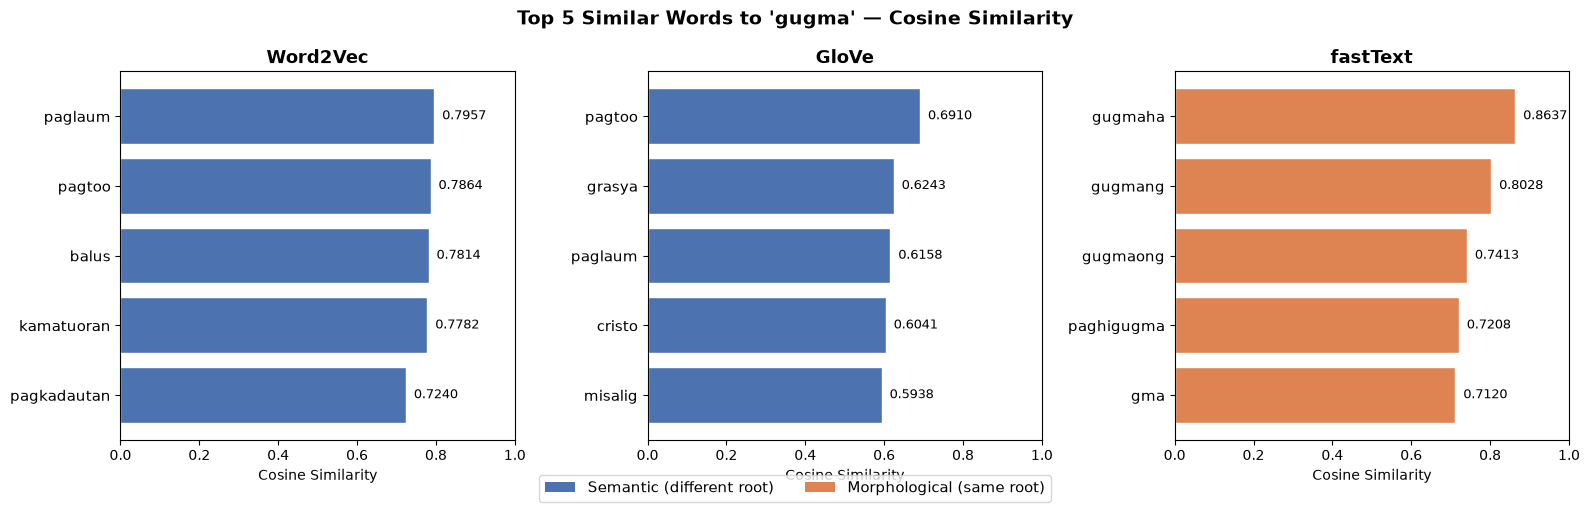

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Top 5 similar words for 'gugma' from each model
models = {
    "Word2Vec": {
        "words":  ["paglaum", "pagtoo", "balus", "kamatuoran", "pagkadautan"],
        "scores": [0.7957, 0.7864, 0.7814, 0.7782, 0.7240],
        "type":   ["semantic", "semantic", "semantic", "semantic", "semantic"]
    },
    "GloVe": {
        "words":  ["pagtoo", "grasya", "paglaum", "cristo", "misalig"],
        "scores": [0.6910, 0.6243, 0.6158, 0.6041, 0.5938],
        "type":   ["semantic", "semantic", "semantic", "semantic", "semantic"]
    },
    "fastText": {
        "words":  ["gugmaha", "gugmang", "gugmaong", "paghigugma", "gma"],
        "scores": [0.8637, 0.8028, 0.7413, 0.7208, 0.7120],
        "type":   ["morphological", "morphological", "morphological", "morphological", "morphological"]
    }
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Top 5 Similar Words to 'gugma' — Cosine Similarity", fontsize=14, fontweight='bold')

colors = {"semantic": "#4C72B0", "morphological": "#DD8452"}

for ax, (model_name, data) in zip(axes, models.items()):
    bar_colors = [colors[t] for t in data["type"]]
    bars = ax.barh(range(len(data["words"])), data["scores"], color=bar_colors, edgecolor='white')
    ax.set_yticks(range(len(data["words"])))
    ax.set_yticklabels(data["words"], fontsize=11)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel("Cosine Similarity")
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.invert_yaxis()

    for bar, score in zip(bars, data["scores"]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{score:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors["semantic"], label="Semantic (different root)"),
                   Patch(facecolor=colors["morphological"], label="Morphological (same root)")]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11, 
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()


**I declare upon my honor that:**

I did all of the codes here with minimal AI :))  
I did all the reasoning for each letter with Claude helping me correct the grammar structure.  
I used AI on helping me organized my thoughts.  
I used AI to help me understand how the algorithms work easily.  